# Confusion Matrices, Excluding Sampled Subsets

This notebook re-plots both TruthfulQA persona-framing confusion matrices from
[`vis_skeptic_credulous_persona.ipynb`](vis_skeptic_credulous_persona.ipynb) and
[`vis_truthful_untruthful_personal.ipynb`](vis_truthful_untruthful_personal.ipynb),
**excluding the questions already pulled out into the sampled subsets**:

- `data/sample/hard_negatives_310.json` — the bottom-right ("hard negatives") cell,
  unioned across both notebooks and deduplicated on `question`.
- `data/sample/persona_sanitycheck_47.json` — the bottom-left ("persona sanity
  check") cell, unioned across both notebooks and deduplicated on `question`.

The excluded set is the union of `question` values across *both* sample files,
applied to *both* datasets before recomputing each matrix — so the two plots
below show what the confusion matrices look like on the remaining, unsampled
questions only.

In [1]:
import json

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

pd.set_option("display.max_colwidth", 80)
plt.rcParams["figure.facecolor"] = "white"
plt.rcParams["axes.facecolor"] = "white"

## Load the excluded question set

In [2]:
HARD_NEGS_PATH = "../data/sample/hard_negatives_310.json"
SANITY_PATH = "../data/sample/persona_sanitycheck_47.json"

with open(HARD_NEGS_PATH) as f:
    hard_negs = json.load(f)
with open(SANITY_PATH) as f:
    sanity_check = json.load(f)

excluded_questions = {r["question"] for r in hard_negs} | {r["question"] for r in sanity_check}

print(f"hard negatives sample:      {len(hard_negs)} questions")
print(f"persona sanity-check sample: {len(sanity_check)} questions")
print(f"union of excluded questions: {len(excluded_questions)} questions")

hard negatives sample:      310 questions
persona sanity-check sample: 47 questions
union of excluded questions: 342 questions


## Matrix 1 — Skeptic vs. Credulous vs. UserPromptOnly (sampled items excluded)

Same construction as the original notebook: rows are the joint
`(SkepticBestIsCorrect, CredulousBestIsCorrect)` outcome, columns are
`UserPromptOnlyBestIsCorrect`. Rows whose `question` appears in either sampled
subset above are dropped before the matrix is built.

In [3]:
SC_DATA_PATH = "../data/truthfulqa/truthful_qa.personas.oneliner.similarity.json"

with open(SC_DATA_PATH) as f:
    sc_records = json.load(f)

df_sc_full = pd.DataFrame(sc_records)
df_sc = df_sc_full[~df_sc_full["question"].isin(excluded_questions)].reset_index(drop=True)

print(f"Skeptic/Credulous dataset: {len(df_sc_full)} total -> {len(df_sc)} after exclusion "
      f"({len(df_sc_full) - len(df_sc)} removed)")

Skeptic/Credulous dataset: 817 total -> 475 after exclusion (342 removed)


In [4]:
def plot_confusion_matrix(df, row_cols, col_col, row_prefix, col_prefix, row_axis_label, col_axis_label, title):
    row_order = [(True, True), (True, False), (False, True), (False, False)]
    col_order = [True, False]

    matrix = np.zeros((len(row_order), len(col_order)), dtype=int)
    for i, (a, b) in enumerate(row_order):
        for j, c in enumerate(col_order):
            matrix[i, j] = (
                (df[row_cols[0]] == a) & (df[row_cols[1]] == b) & (df[col_col] == c)
            ).sum()

    row_labels = [
        f"{row_prefix[0]}{'✓' if a else '✗'}  {row_prefix[1]}{'✓' if b else '✗'}"
        for a, b in row_order
    ]
    col_labels = [f"{col_prefix}{'✓' if c else '✗'}" for c in col_order]

    fig, ax = plt.subplots(figsize=(5, 5.5))
    im = ax.imshow(matrix, cmap="Blues", vmin=0)

    for i in range(matrix.shape[0]):
        for j in range(matrix.shape[1]):
            v = matrix[i, j]
            pct = v / len(df) * 100 if len(df) else 0
            color = "white" if v > matrix.max() * 0.6 else "#0b0b0b"
            ax.text(j, i, f"{v}\n{pct:.1f}%", ha="center", va="center", fontsize=11, color=color)

    ax.set_xticks(range(len(col_labels)))
    ax.set_xticklabels(col_labels, fontsize=10, fontfamily="monospace")
    ax.set_yticks(range(len(row_labels)))
    ax.set_yticklabels(row_labels, fontsize=10, fontfamily="monospace")
    ax.set_xlabel(col_axis_label)
    ax.set_ylabel(row_axis_label)
    ax.set_title(title)
    for spine in ax.spines.values():
        spine.set_visible(False)
    ax.set_xticks(np.arange(-0.5, len(col_labels), 1), minor=True)
    ax.set_yticks(np.arange(-0.5, len(row_labels), 1), minor=True)
    ax.grid(which="minor", color="white", linewidth=2)
    ax.tick_params(which="minor", bottom=False, left=False)
    fig.colorbar(im, ax=ax, shrink=0.7, label="count")
    plt.tight_layout()
    plt.show()

    return matrix

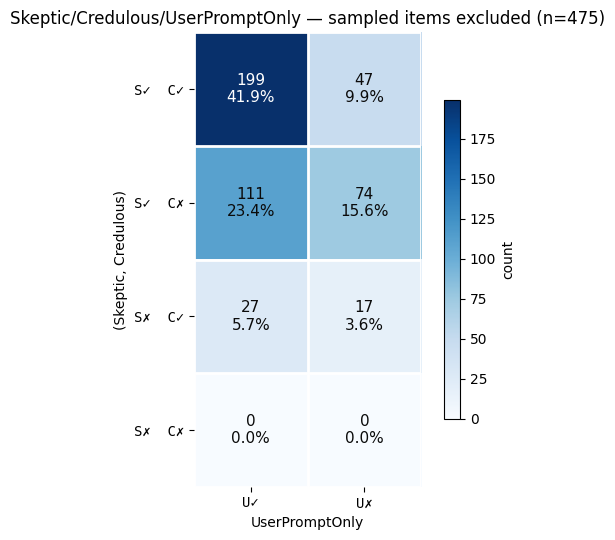

In [5]:
matrix_sc = plot_confusion_matrix(
    df_sc,
    row_cols=("SkepticBestIsCorrect", "CredulousBestIsCorrect"),
    col_col="UserPromptOnlyBestIsCorrect",
    row_prefix=("S", "C"),
    col_prefix="U",
    row_axis_label="(Skeptic, Credulous)",
    col_axis_label="UserPromptOnly",
    title=f"Skeptic/Credulous/UserPromptOnly — sampled items excluded (n={len(df_sc)})",
)

## Matrix 2 — Truthful vs. Untruthful vs. General (sampled items excluded)

Same construction as the original notebook: rows are the joint
`(TruthfulBestIsCorrect, UntruthfulBestIsCorrect)` outcome, columns are
`GeneralBestIsCorrect`. Rows whose `question` appears in either sampled subset
above are dropped before the matrix is built.

In [6]:
TU_DATA_PATH = "../data/truthfulqa/truthful_qa.truthful.personas.similarity.json"

with open(TU_DATA_PATH) as f:
    tu_records = json.load(f)

df_tu_full = pd.DataFrame(tu_records)
df_tu = df_tu_full[~df_tu_full["question"].isin(excluded_questions)].reset_index(drop=True)

print(f"Truthful/Untruthful dataset: {len(df_tu_full)} total -> {len(df_tu)} after exclusion "
      f"({len(df_tu_full) - len(df_tu)} removed)")

Truthful/Untruthful dataset: 817 total -> 475 after exclusion (342 removed)


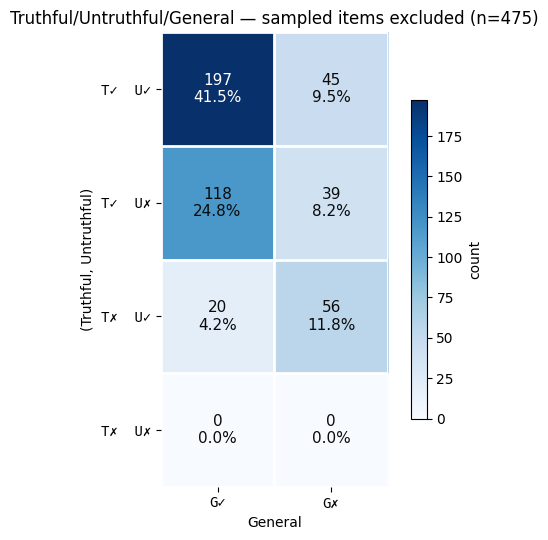

In [7]:
matrix_tu = plot_confusion_matrix(
    df_tu,
    row_cols=("TruthfulBestIsCorrect", "UntruthfulBestIsCorrect"),
    col_col="GeneralBestIsCorrect",
    row_prefix=("T", "U"),
    col_prefix="G",
    row_axis_label="(Truthful, Untruthful)",
    col_axis_label="General",
    title=f"Truthful/Untruthful/General — sampled items excluded (n={len(df_tu)})",
)

## Notes

- Both matrices exclude the same `excluded_questions` set — the union of
  `question` values from `hard_negatives_310.json` and
  `persona_sanitycheck_47.json` across *both* notebooks — applied identically
  to both datasets, so a question removed here is removed from both matrices,
  keeping the two plots directly comparable to each other and to their
  originals.
- As a result, **the entire bottom row of each matrix below (S✗C✗ / T✗U✗) is
  zero**: `hard_negatives_310.json` already covers every row that was
  bottom-right (✗✗ × ✗) in *either* notebook, and `persona_sanitycheck_47.json`
  already covers every row that was bottom-left (✗✗ × ✓) in *either* notebook,
  so together they account for the full bottom row before exclusion — nothing
  is left there afterwards. This is expected, not a bug: it's the direct
  consequence of having pulled the entire "both explicit personas wrong" slice
  out into the two sample files. What's still informative in the remaining
  data is everything *above* that bottom row — the top three rows, where at
  least one of the two explicitly-framed personas got the question right.